In [1]:
%load_ext autoreload
%autoreload 2

## Training and Validation for Torchvision Maskrcnn on Volpy Data 
Tutorial for training and valdiation Maskrcnn model

@authors: Changjia Cai, Erik Thompson, and Manuel Paez

Date Created: August 28th, 2024

Date Updated: July 7th, 2025

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import os
from skimage.color import rgb2gray, gray2rgb
import torch
from torch.optim.lr_scheduler import CyclicLR
from torch.utils.data import Dataset, DataLoader
from torchvision import tv_tensors
from tqdm import tqdm

from config import Config
from inference import mrcnn_inference, thresholded_predictions 
from model import get_model_instance_segmentation
from neurons import NeuronsDataset, collate_fn, train_one_epoch, validate, perform_final_evaluation
from utils import ScaleImage, apply_masks, draw_boxes, data_transform, nf_match_neurons_in_binary_masks, normalize_image, vp_load_image, f1_score

Check if cuda is available

In [3]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(f"Using device: {device}")

Using device: cuda


## Volpy Data, Training, and Validation Sets
There are 24 datasets in total, 3 types of different voltage imaging datasets recorded from mouse L1 cortex (L1), mouse hippocampus (HPC), and zebrafish tegmental area (TEG). Set up the image directories from https://zenodo.org/records/4515768 as follows:

    volpy_training_data/
        images/
            HPC.29.04.npz
            ...
        masks/
            HPC.29.04_mask.npz
            ...      

### Config 
The base configuration class 'Config' from 'config.py' contains the variables necessary for training and validation on the Volpy Dataset. The following 'DATASET_PATH' should be directed to 'volpy_training_data'. 

    Config: 
        # Paths
        DATASET_PATH = r'/mnt/home/mpaez/ceph/volpy_training_data/'
        MODEL_SAVE_DIR = r'/mnt/home/mpaez/ceph/volpy_models/'

        # Model and Training Hyperparameters
        NUM_CLASSES = 1 + 1  # Background + Neuron
        BATCH_SIZE = 2 
        NUM_EPOCHS = 100
        MAX_LR = 0.005
        BASE_LR = 0.000001
        STEP_SIZE_UP = 3
        STEP_SIZE_DOWN = 7

        # Data Loading, Splitting, and Inference
        # IMAGES_PER_GPU = 2
        RANDOM_SPLIT = False # True for random split, False for fixed split from map below.
        NUM_TEST_RANDOM = 8
        NUM_TORCH_WORKERS = 4 
        DATASET_REGION_MAP = {
            'HPC': [0, 1, 2, 3],
            'L1': [12, 13, 14],
            'TEG': [21],
            'Train': [4, 5, 6, 7, 8, 9, 10, 11, 15, 16, 17, 18, 19, 20, 22, 23]
        }

        INFERENCE_THRESHOLD = 0.5

        # Logging and Saving Frequency
        PRINT_FREQ = 1 
        SAVE_FREQ = 20 

### Dataset 

Building on the standard `torch.utils.data.Dataset`class, we use 'NeuronsDataset' from neurons.py. The  `__getitem__` method of this class should return an `image` and a `target` dictionary delineating the different objects (box/mask) in the image:

    image: torchvision.tv_tensors.Image of shape [3, H, W]: can be a pure tensor, or a PIL Image of size (H, W)
    target: a dict containing the following keys
        masks : torchvision uint8 binary masks for each object (N,H,W) (N masks)
        boxes (bounding boxes)  (nx4)
        labels (int) label for each bounding box (note 0 is background, so if you have no bg, start with 1)
        image_id (int) unique image id
        area (float) area of bounding box 
        iscrowd (uint8) instances with `iscrowd=True` will be ignored during evaluation 

The 'data_transform' function from neurons.py should return a training pipeline for training. 
For windows, set the number of workers to 0. Otherwise, set to 4+

#### Dataset Split
The dataset split can be randomized split (such that each of L1, HPC, and TEG has a validation and training set) or can be set fixed. 

#### Data Transforms
From 'utils.py':

        transforms.append(T.RandomHorizontalFlip(p=0.5))
        transforms.append(T.RandomVerticalFlip(p=0.5))
        transforms.append(T.RandomApply([T.RandomRotation(degrees=(-5, 5))], p=0.5))
        transforms.append(T.ColorJitter(brightness=0.5,
                                        contrast=0.5,
                                        saturation=0.5,
                                        hue=0))
        transforms.append(T.GaussianBlur(kernel_size=(5, 5), sigma=(0.001, 0.3)))
        transforms.append(T.SanitizeBoundingBoxes(min_size=2))

In [4]:
config = Config()
""" Main function to run the training and validation pipeline."""
os.makedirs(config.MODEL_SAVE_DIR, exist_ok=True)

print("Loading datasets...")
dataset_train = NeuronsDataset(config.DATA_DIR, data_transform(train=True))
dataset_val = NeuronsDataset(config.DATA_DIR, data_transform(train=False))

if config.RANDOM_SPLIT:
    print("Using random split for train/validation sets.")
    indices = list(range(len(dataset_train_instance)))
    np.random.shuffle(indices)
    train_indices = indices[:-config.NUM_TEST_RANDOM]
    val_indices = indices[-config.NUM_TEST_RANDOM:]
else:
    print("Using fixed split based on DATASET_REGION_MAP.")
    train_indices = config.DATASET_REGION_MAP['Train']
    val_indices = [idx for region, inds in config.DATASET_REGION_MAP.items() if region != 'Train' for idx in inds]
    
val_indices_path = os.path.join(config.MODEL_SAVE_DIR, 'validation_indices.npy')
np.save(val_indices_path, val_indices)
print(f"Validation indices for this run have been saved to {val_indices_path}")

dataset_train = torch.utils.data.Subset(dataset_train, train_indices)
dataset_val = torch.utils.data.Subset(dataset_val, val_indices)

data_loader_train = DataLoader(dataset_train, batch_size=config.BATCH_SIZE, shuffle=True,
                                   num_workers=config.NUM_TORCH_WORKERS, collate_fn=collate_fn)
data_loader_val = DataLoader(dataset_val, batch_size=1, shuffle=False,
                                 num_workers=config.NUM_TORCH_WORKERS, collate_fn=collate_fn)

Loading datasets...
Using fixed split based on DATASET_REGION_MAP.
Validation indices for this run have been saved to /mnt/home/mpaez/ceph/volpy_models/validation_indices.npy


### Model
We use a model pre-trained on the COCO dataset, and fine-tune the last layer. 

### Optimizer + lr scheduler
We use the SGD optimizer and a CycleLR scheduler 

In [5]:
# Model
model = get_model_instance_segmentation(config.NUM_CLASSES)
model.to(device)

# Optimizer + lr scheduler
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=config.MAX_LR, momentum=0.9, weight_decay=0.0001) 
lr_scheduler = CyclicLR(optimizer, base_lr=config.BASE_LR, # Initial learning rate which is the lower boundary in the cycle for each parameter group
                        max_lr=config.MAX_LR, # Upper learning rate boundaries in the cycle for each parameter group
                        step_size_up=config.STEP_SIZE_UP, # Number of training iterations in the increasing half of a cycle
                        step_size_down=config.STEP_SIZE_DOWN,
                        mode="triangular2")

### Training the Network

In [6]:
all_train_losses, all_val_losses, all_lrs = [], [], []
print(f"**TRAIN {config.NUM_EPOCHS} epochs. PRINT every {config.PRINT_FREQ} epoch(s). "
          f"SAVE every {config.SAVE_FREQ} epoch(s).**")

for epoch in range(config.NUM_EPOCHS):
    train_loss = train_one_epoch(model, optimizer, data_loader_train, device, epoch)
    val_loss = validate(model, data_loader_val, device, epoch)
    current_lr = optimizer.param_groups[0]["lr"]

    all_train_losses.append(train_loss)
    all_val_losses.append(val_loss)
    all_lrs.append(current_lr)

    lr_scheduler.step()

    if (epoch + 1) % config.PRINT_FREQ == 0:
        print(f"Epoch {epoch+1}/{config.NUM_EPOCHS} | Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, LR: {current_lr:.6f}")

    if (epoch + 1) % config.SAVE_FREQ == 0:
        model_path = os.path.join(config.MODEL_SAVE_DIR, f'mrcnn_epoch_{epoch+1}.pt')
        torch.save(model.state_dict(), model_path)
        print(f"\t Model saved to {model_path}")

history = {'train_loss': all_train_losses, 'val_loss': all_val_losses, 'lr': all_lrs}
torch.save(history, os.path.join(config.MODEL_SAVE_DIR, 'volpy_train_history.pt'))
print("\nDONE!")

**TRAIN 100 epochs. PRINT every 1 epoch(s). SAVE every 20 epoch(s).**


Epoch 1 [val]: 100%|██████████| 8/8 [00:00<00:00, 13.08it/s]


Epoch 1/100 | Train Loss: 4.0867, Val Loss: 3.9657, LR: 0.000001


Epoch 2 [val]: 100%|██████████| 8/8 [00:00<00:00, 21.00it/s]


Epoch 2/100 | Train Loss: 2.3240, Val Loss: 2.1983, LR: 0.001667


...

Epoch 98/100 | Train Loss: 0.9649, Val Loss: 1.1690, LR: 0.000005


Epoch 99 [val]: 100%|██████████| 8/8 [00:00<00:00, 21.12it/s]


Epoch 99/100 | Train Loss: 0.9509, Val Loss: 1.1645, LR: 0.000004


Epoch 100 [val]: 100%|██████████| 8/8 [00:00<00:00, 21.11it/s]


Epoch 100/100 | Train Loss: 0.9446, Val Loss: 1.1568, LR: 0.000002
	 Model saved to /mnt/home/mpaez/ceph/volpy_models/mrcnn_epoch_100.pt

DONE!


### Plot Loss Function 

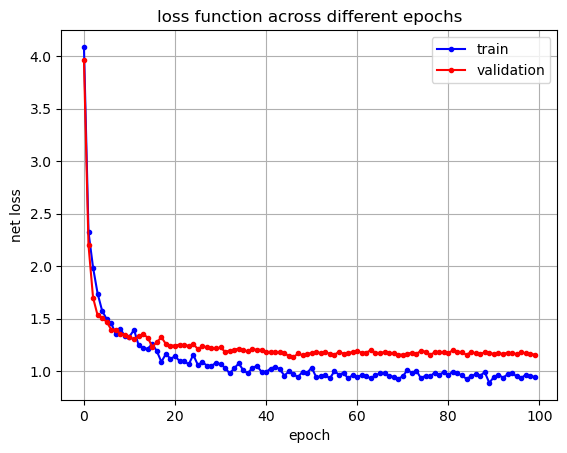

In [7]:
plt.plot(np.array(all_train_losses), color='blue', marker='.', label='train')
plt.plot(np.array(all_val_losses), color='red', marker='.', label='validation')
plt.legend()
plt.xlabel('epoch')
plt.ylabel('net loss')
plt.title('loss function across different epochs')
plt.grid()

### Plot Learning Rate vs Epoch

Text(0.5, 1.0, 'learning rate across different epochs')

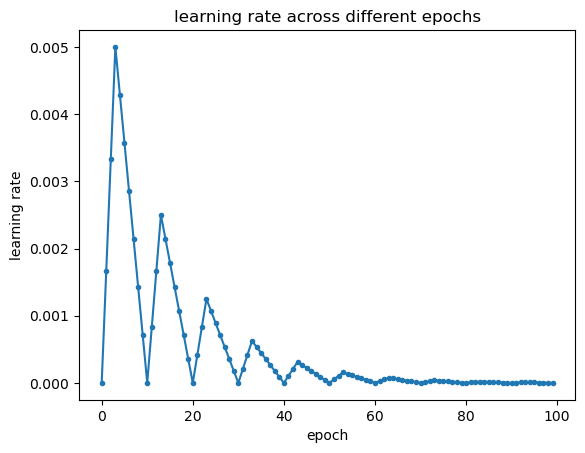

In [8]:
plt.plot(all_lrs, marker='.')
plt.xlabel('epoch')
plt.ylabel('learning rate')
plt.title('learning rate across different epochs')

### Inference using Test Set

For this, we will compute F1 scores for all datasets

#### Perform_final_evaluation 
From 'neurons.py', runs inference on the validtion set, calculates F1 scores for each region (i.e. HPC, L1, TEG), and reports the results. 


Loaded 8 validation indices for final evaluation.

Calculating F1 scores...


Evaluation:   0%|          | 0/8 [00:00<?, ?it/s]

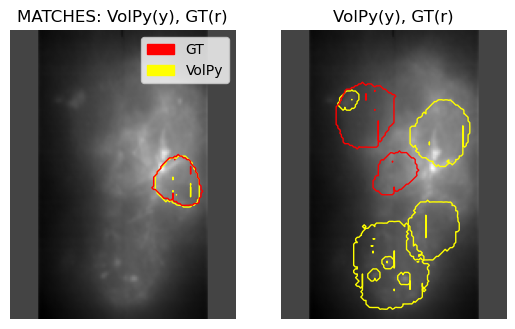

Evaluation:  12%|█▎        | 1/8 [00:00<00:02,  2.93it/s]

F1 score for validation image index 0: 0.1818


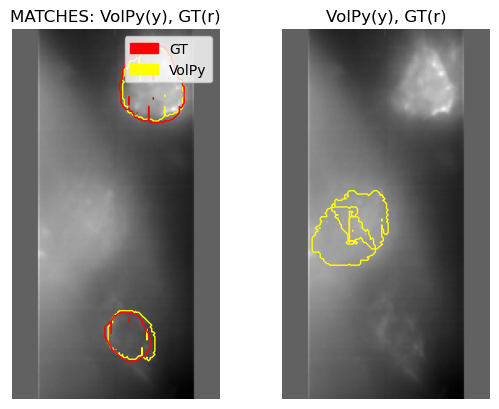

Evaluation:  25%|██▌       | 2/8 [00:00<00:01,  4.22it/s]

F1 score for validation image index 1: 0.6667


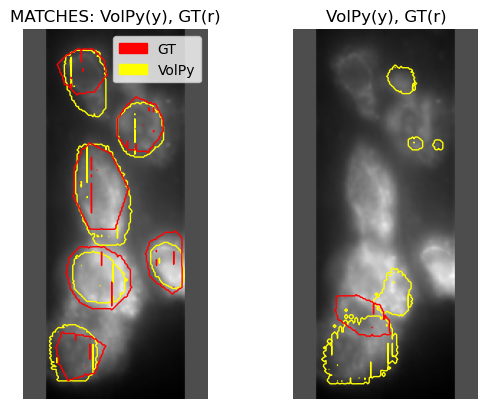

Evaluation:  38%|███▊      | 3/8 [00:00<00:01,  4.29it/s]

F1 score for validation image index 2: 0.6667


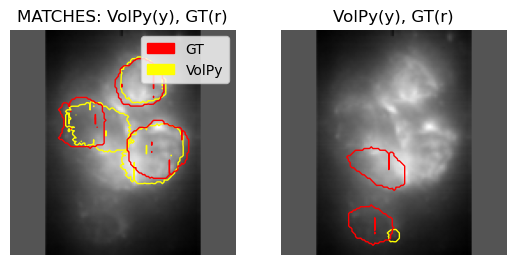

Evaluation:  50%|█████     | 4/8 [00:00<00:00,  4.99it/s]

F1 score for validation image index 3: 0.6667


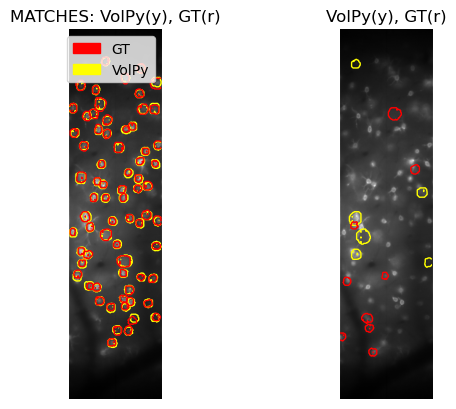

Evaluation:  62%|██████▎   | 5/8 [00:02<00:02,  1.48it/s]

F1 score for validation image index 12: 0.9032


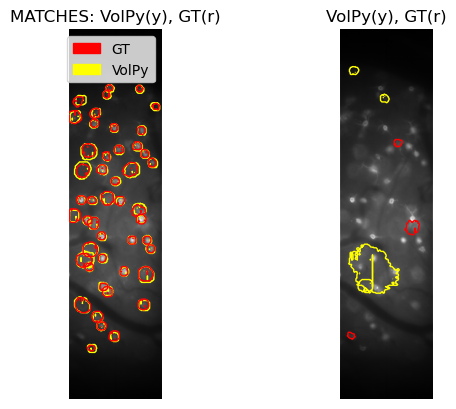

Evaluation:  75%|███████▌  | 6/8 [00:03<00:01,  1.26it/s]

F1 score for validation image index 13: 0.9307


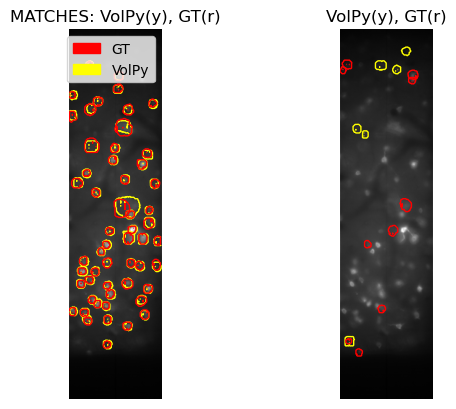

Evaluation:  88%|████████▊ | 7/8 [00:04<00:00,  1.06it/s]

F1 score for validation image index 14: 0.8730


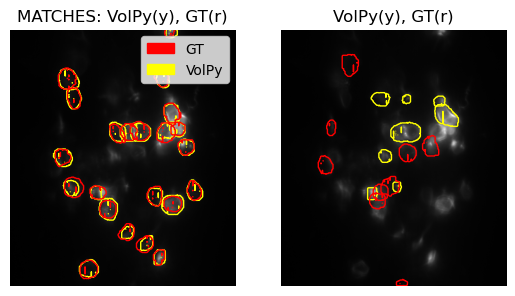

Evaluation: 100%|██████████| 8/8 [00:05<00:00,  1.42it/s]

F1 score for validation image index 21: 0.7213

Overall Average F1 score: 0.7013

Average F1 scores by region:
Average F1 score for HPC: 0.5455
Average F1 score for L1: 0.9023
Average F1 score for TEG: 0.7213


<Figure size 640x480 with 0 Axes>

In [9]:
"""Loads a trained model and runs inference on the validation set."""
val_indices_path = os.path.join(config.MODEL_SAVE_DIR, 'validation_indices.npy')
    
val_indices = np.load(val_indices_path)

full_dataset = NeuronsDataset(config.DATA_DIR, data_transform(train=False))
dataset_val = torch.utils.data.Subset(full_dataset, val_indices)
data_loader_val = DataLoader(dataset_val, batch_size=1, shuffle=False, num_workers=config.NUM_TORCH_WORKERS, collate_fn=collate_fn)

perform_final_evaluation(model, config, device, plot_results=True)